# KNN Fault Detection — C90L-4 Motor
**Labels:** 0 = Normal | 1 = Warning | 2 = Critical

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset

In [3]:
data = pd.read_csv("../artifacts/sensor_data3.csv")
print("Shape:", data.shape)
data.tail()

Shape: (3000, 6)


,Time(s),vibration_mm_s,temperature_C,current_A,label,speed_RPM
2995,996,8.618,81.0,3.653,2,1250
2996,997,9.187,79.8,3.582,2,1200
2997,998,9.156,80.5,3.648,2,1215
2998,999,8.106,81.4,3.721,2,1265
2999,1000,7.251,77.6,3.589,2,1250


## 3. Exploratory Data Analysis

In [4]:
print("Label distribution:")
print(data['label'].value_counts())
print()
data.info()

Label distribution:
label
0    1000
1    1000
2    1000
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time(s)         3000 non-null   int64  
 1   vibration_mm_s  3000 non-null   float64
 2   temperature_C   3000 non-null   float64
 3   current_A       3000 non-null   float64
 4   label           3000 non-null   int64  
 5   speed_RPM       3000 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 140.8 KB


In [5]:
data.describe()

,Time(s),vibration_mm_s,temperature_C,current_A,label,speed_RPM
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,500.500000,6.016558,64.302767,3.330337,1.000000,1329.803333
std,288.723115,2.612406,11.703596,0.331599,0.816633,59.986199
min,1.000000,0.818000,38.700000,2.462000,0.000000,1145.000000
25%,250.750000,3.441500,53.500000,3.042000,0.000000,1275.000000
50%,500.500000,5.814500,65.000000,3.407000,1.000000,1340.000000
75%,750.250000,8.427250,75.300000,3.598000,2.000000,1390.000000
max,1000.000000,12.125000,86.700000,3.987000,2.000000,1420.000000


## 4. Feature & Label Selection

In [6]:
# Features: columns 1 to 3 (vibration, temperature, current)
x = data.iloc[:, 1:4]
print("Features:")
x.head()

Features:


,vibration_mm_s,temperature_C,current_A
0,3.027,51.6,2.944
1,2.259,46.4,2.502
2,2.428,51.9,3.339
3,3.565,51.5,2.978
4,2.992,52.4,3.074


In [8]:
# Label: last column
y = data.iloc[:, -2]
print("Labels:")
y.value_counts()

Labels:


label
0    1000
1    1000
2    1000
Name: count, dtype: int64

## 5. Train-Test Split  *(split BEFORE scaling to prevent data leakage)*

In [9]:
# FIX: split first, then scale — avoids test data leaking into scaler
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", x_train.shape)
print("Testing  set shape:", x_test.shape)

Training set shape: (2400, 3)
Testing  set shape: (600, 3)


## 6. Feature Scaling  *(fit on train only, transform both)*

In [10]:
scaler = StandardScaler()

# FIX: fit_transform on train, only transform on test
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

print("Scaling complete.")
print("First 5 scaled training rows:")
print(x_train[:5])

Scaling complete.
First 5 scaled training rows:
[[ 1.96970894  0.82916173  1.36691404]
 [-1.08060158 -1.68700348 -1.67348511]
 [-1.21114922 -1.21788793 -1.00924696]
 [ 1.74487689  1.13621918  0.98648674]
 [ 1.13298254  1.56268786  1.30954802]]


## 7. Train KNN Model (K=5 as baseline)

In [11]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

pred = model.predict(x_test)

train_pred_base = model.predict(x_train)
train_acc_base  = accuracy_score(y_train, train_pred_base)
test_acc_base   = accuracy_score(y_test, pred)

print(f"Training Accuracy (K=5): {train_acc_base * 100:.2f}%")
print(f"Testing  Accuracy (K=5): {test_acc_base  * 100:.2f}%")

Training Accuracy (K=5): 100.00%
Testing  Accuracy (K=5): 100.00%


## 8. Confusion Matrix

Confusion Matrix:
[[200   0   0]
 [  0 200   0]
 [  0   0 200]]


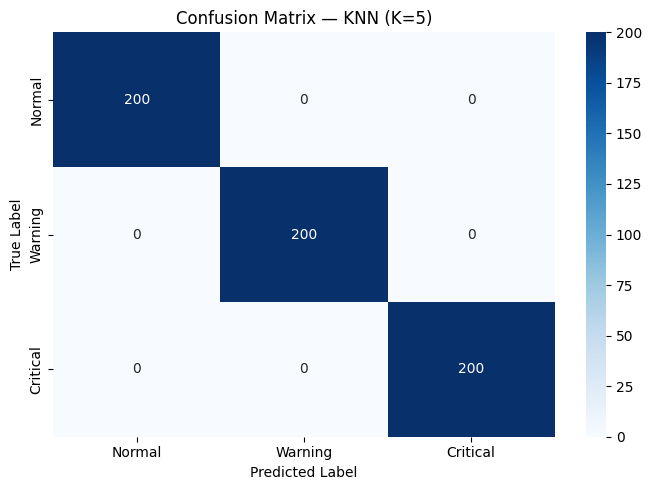

In [12]:
cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Warning', 'Critical'],
    yticklabels=['Normal', 'Warning', 'Critical']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — KNN (K=5)')
plt.tight_layout()
plt.show()

## 9. Classification Report

In [13]:
print(classification_report(
    y_test, pred,
    target_names=['Normal (0)', 'Warning (1)', 'Critical (2)']
))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       200
 Warning (1)       1.00      1.00      1.00       200
Critical (2)       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



## 10. Find Best K — Training vs Testing Accuracy

In [14]:
train_acc = []
test_acc  = []

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)

    train_acc.append(accuracy_score(y_train, knn.predict(x_train)))
    test_acc.append(accuracy_score(y_test,  knn.predict(x_test)))

best_k   = test_acc.index(max(test_acc)) + 1
best_acc = max(test_acc)

print(f"Best K        : {best_k}")
print(f"Best Test Acc : {best_acc * 100:.2f}%")
print(f"Train Acc @ K=1 : {train_acc[0]*100:.2f}%  (overfitting check)")

Best K        : 1
Best Test Acc : 100.00%
Train Acc @ K=1 : 100.00%  (overfitting check)


## 11. Accuracy vs K Plot

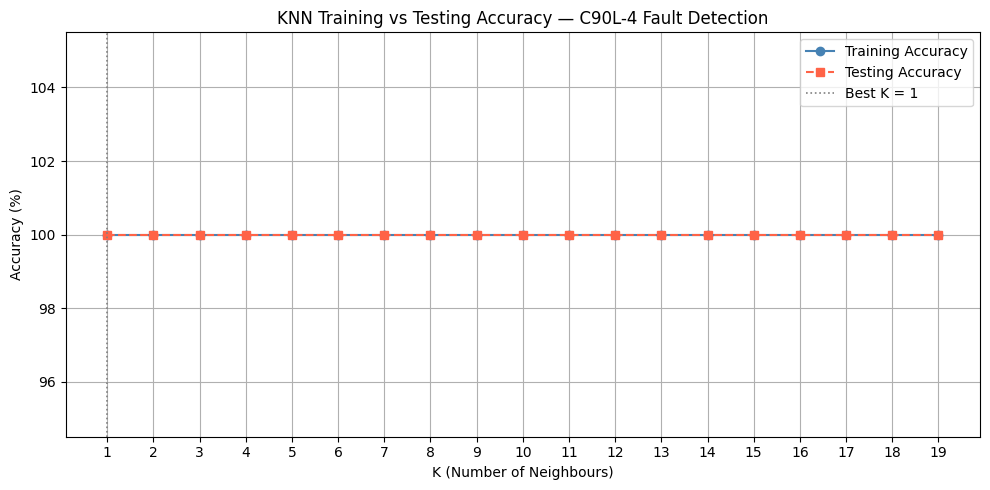

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 20), [a * 100 for a in train_acc],
         marker='o', label='Training Accuracy', color='steelblue')
plt.plot(range(1, 20), [a * 100 for a in test_acc],
         marker='s', label='Testing Accuracy',  color='tomato', linestyle='--')

plt.axvline(x=best_k, color='gray', linestyle=':', linewidth=1.2,
            label=f'Best K = {best_k}')

plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Accuracy (%)')
plt.title('KNN Training vs Testing Accuracy — C90L-4 Fault Detection')
plt.xticks(range(1, 20))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Accuracy Table (all K values)

In [ ]:
result = pd.DataFrame({
    'K': range(1, 20),
    'Training Accuracy (%)': [round(a * 100, 2) for a in train_acc],
    'Testing Accuracy (%)' : [round(a * 100, 2) for a in test_acc]
})
result

## 13. Final Model with Best K

In [15]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train, y_train)

final_pred       = final_model.predict(x_test)
final_train_pred = final_model.predict(x_train)

final_train_acc = accuracy_score(y_train, final_train_pred)
final_test_acc  = accuracy_score(y_test,  final_pred)

print(f"=== Final Model (K={best_k}) ===")
print(f"Training Accuracy : {final_train_acc * 100:.2f}%")
print(f"Testing  Accuracy : {final_test_acc  * 100:.2f}%")
print()
print(classification_report(
    y_test, final_pred,
    target_names=['Normal (0)', 'Warning (1)', 'Critical (2)']
))

=== Final Model (K=1) ===
Training Accuracy : 100.00%
Testing  Accuracy : 100.00%

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       200
 Warning (1)       1.00      1.00      1.00       200
Critical (2)       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



## 14. Prediction vs Actual (sample check)

In [16]:
comparison = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': final_pred
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
print(f"Correct predictions: {comparison['Correct'].sum()} / {len(comparison)}")
comparison.head(20)

Correct predictions: 600 / 600


,Actual,Predicted,Correct
0,2,2,True
1,2,2,True
2,1,1,True
3,0,0,True
4,2,2,True
5,2,2,True
6,0,0,True
7,1,1,True
8,2,2,True
9,1,1,True


In [15]:
import pickle
with open ('../Model/knn.pickle','wb') as file:
    pickle.dump(model,file)